# Analytic limits of the single-species ion transport matrix

A circular, large-aspect-ratio tokamak with one ion species (deuterium) is driven
separately by a temperature gradient, a density gradient, and a radial electric field.
For each drive we record the three moments yancc returns: the conductive heat flux, the
particle flux, and the parallel flow $\langle B V_\parallel \rangle$.

References:

* **Exact at any collisionality** (momentum conservation in like-particle collisions):
  the particle flux vanishes for every drive; the density and $E_\rho$ drives give no heat
  flux and a purely diamagnetic flow $\langle B V_\parallel\rangle = K T/(Ze)$, with
  $K = G/(\iota \psi')$.
* **Banana regime** ($\nu^* \ll 1$, $\epsilon \to 0$): Helander & Sigmar (11.29)-(11.31),
  $\langle B V_\parallel\rangle_T/(KT/Ze) = 1 - 1.17 f_c$ and
  $q = 0.92 f_t \, n T^2 K^2 m/(Z^2 e^2 \langle B^2\rangle \tau_i)$ for $d\ln T/d\rho = -1$.
* **Pfirsch-Schlüter regime** ($\nu^* \gg \epsilon^{-3/2}$): Helander & Sigmar (9.8),
  $q = (25/4\kappa_\parallel) \, n T^2 K^2 m/(Z^2 e^2 \tau_i) \, \langle B^{-2} - \langle B^2\rangle^{-1}\rangle$
  with Braginskii's $\kappa_\parallel = 3.906$, exact in geometry; and Hazeltine (1974) eq. (61),
  $\langle B V_\parallel\rangle_T/(KT/Ze) = 1 + 1.8 + 0.27 b$, from a variational
  solution quoted as accurate to about 20%.
* The Chang-Hinton interpolation (Helander & Sigmar p. 238) is shown as a guide.

Here $\tau_i = \sqrt{2}\tau_{ii}$ (Helander & Sigmar (1.5)) and $\nu^*_i$ is the Sauter definition.

In [1]:
import os
import pickle
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from jax import config

config.update("jax_enable_x64", True)

sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../../"))

from scipy.constants import elementary_charge, epsilon_0
from scipy.integrate import quad

from yancc import (
    Deuterium,
    Field,
    LocalMaxwellian,
    MaxwellSpeedGrid,
    UniformPitchAngleGrid,
    solve_dke,
)

# Setup

In [2]:
QUICK = False

R0, q, B0, rho = 3.0, 2.0, 1.0, 0.5
T_EV = 1.0e3
LNLAMBDA = 17.0
KAPPA_PAR = 3.906  # Braginskii ion parallel heat conductivity, Z = 1
# E_rho drive in V; small enough that E x B drift is negligible next to poloidal
# streaming even at eps = 0.01, where the poloidal field is weak. Results are rescaled
# to the drive A1 of the density gradient.
ERHO = 0.1

e = elementary_charge
m_i = float(Deuterium.mass)
Z = float(Deuterium.charge) / e
T_J = T_EV * e

datafile = "benchmark_circular_tokamak" + ("_quick" if QUICK else "") + ".pkl"

In [3]:
def circular_tokamak_field(ntheta, eps):
    """Circular tokamak surface, |B| = B0 / (1 + eps cos theta), Boozer coordinates."""
    # no toroidal current, G = B0 R0, iota = 1/q, and Psi = pi a^2 B0 so that rho = r/a
    a = eps * R0 / rho
    theta = np.linspace(0, 2 * np.pi, ntheta, endpoint=False)
    Bmag = (B0 / (1 + eps * np.cos(theta)))[:, None]
    return Field.from_boozer(
        rho=rho,
        Bmag=Bmag,
        I=0.0,
        G=B0 * R0,
        iota=1 / q,
        Psi=np.pi * a**2 * B0,
        R_major=R0,
        a_minor=a,
        NFP=1,
    )


def fsa(fun, eps, nquad=4096):
    """Flux surface average of fun(B, theta); the Boozer Jacobian is ~ 1/B^2."""
    theta = np.linspace(0, 2 * np.pi, nquad, endpoint=False)
    B = B0 / (1 + eps * np.cos(theta))
    w = 1 / B**2
    return np.sum(w * fun(B, theta)) / np.sum(w)


def trapped_fraction(eps):
    """Effective trapped fraction, Helander & Sigmar (11.24)."""
    B2 = fsa(lambda B, t: B**2, eps)
    integrand = lambda lam: (
        lam / fsa(lambda B, t: np.sqrt(np.clip(1 - lam * B, 0, None)), eps)
    )
    val, _ = quad(integrand, 0, (1 - eps) / B0, limit=200, epsabs=0, epsrel=1e-10)
    return 1 - 0.75 * B2 * val


def hazeltine_b(eps):
    """Hazeltine (1974) factor b = <(b.grad B)^2/B^2> <B^2> / <(b.grad B)^2>."""
    # b.grad B ~ B dB/dtheta in Boozer coordinates
    dB = lambda B, t: B0 * eps * np.sin(t) / (1 + eps * np.cos(t)) ** 2
    num = fsa(lambda B, t: dB(B, t) ** 2, eps) * fsa(lambda B, t: B**2, eps)
    return num / fsa(lambda B, t: B**2 * dB(B, t) ** 2, eps)


def density_for_nustar(eps, nu):
    """Density giving Sauter nu*_i = 4.90e-18 q R n Z^4 lnL / (T^2 eps^3/2)."""
    return nu * T_EV**2 * eps**1.5 / (q * R0 * 4.90e-18 * Z**4 * LNLAMBDA)


def tau_i(n):
    """Ion collision time tau_i = sqrt(2) tau_ii, Helander & Sigmar (1.5)."""
    vth = np.sqrt(2 * T_J / m_i)
    gamma = (Z**2 * e**2) ** 2 * LNLAMBDA / (4 * np.pi * epsilon_0**2 * m_i**2)
    return np.sqrt(2) * 3 * np.sqrt(np.pi) * vth**3 / (4 * gamma * n)

## Resolution

* **Pitch** $n_a$: in the banana regime the trapped-passing boundary layer has width
  $\Delta\xi \sim \sqrt{2\epsilon\nu^*}$, and about 16 points per $\Delta\xi$ (over
  $\xi \in [-1, 1]$) are needed for the heat flux and flow to converge to ~1%. In the
  Pfirsch-Schlüter regime the rigid parallel flow is fixed only by a parallel viscosity
  $\propto 1/\nu$, while the discrete pitch-angle scattering conserves momentum only to
  $O(n_a^{-2})$; the resulting flow error grows like $(\nu^*/n_a^2)^2$, so $n_a \propto \sqrt{\nu^*}$ there.
* **Speed** $n_x$: with Galerkin energy scattering, momentum conservation is spectral in
  $n_x$ and its error is likewise amplified by the collisionality.
* **Poloidal** $n_\theta$: the banana regime needs a finer poloidal grid than the smooth
  collisional regimes.
* **Tolerance**: Condition number scales like $\nu^* n_a^2 n_x^2$ so at higher collisionality the achieveable accuracy is somewhat reduced

In [4]:
def resolution(eps, nu):
    """Grid sizes (nx, na, ntheta) and tolerance for one (eps, nu*) point."""
    na = np.clip(16 / np.sqrt(2 * eps * nu), 121, 3201)
    na = max(na, 241 * np.sqrt(nu / 1e4))
    na = 2 * (int(na) // 2) + 1
    nx = 6 if nu < 0.1 else 10 if nu < 10 else 16
    nt = 121 if nu < 1 else 61
    rtol = 1e-8 if nu < 100 else 1e-6
    return nx, na, nt, rtol


def solve_point(eps, nu, nx, na, nt, rtol, drives="nTE"):
    """Solve each drive at one point and return flows, fluxes and normalizations."""
    field = circular_tokamak_field(nt, eps)
    n = density_for_nustar(eps, nu)
    K = float(field.G) / (float(field.iota) * float(field.psi_rho))
    grids = (field, UniformPitchAngleGrid(na), MaxwellSpeedGrid(nx))
    # (aLT, aLn, Erho) for each drive; aL = -dln/drho
    setup = {"n": (0.0, 1.0, 0.0), "T": (1.0, 0.0, 0.0), "E": (0.0, 0.0, ERHO)}
    out = {
        "eps": eps,
        "nu": nu,
        "nx": nx,
        "na": na,
        "nt": nt,
        "rtol": rtol,
        "V_dia": K * T_J / (Z * e),
        "qscale": n * T_J**2 * K**2 * m_i / (Z**2 * e**2 * tau_i(n)),
        "mu_star": q * R0 / (np.sqrt(2 * T_J / m_i) * tau_i(n) * eps**1.5),
    }
    t0 = time.perf_counter()
    for d in drives:
        aLT, aLn, Erho = setup[d]
        species = [LocalMaxwellian.from_scale_lengths(Deuterium, T_EV, n, aLT, aLn)]
        sol, info = solve_dke(
            *grids, species, Erho, coulomb_log=LNLAMBDA, rtol=rtol, verbose=2
        )
        # E_rho enters only through A1 = dln n/drho + Z (dPhi/drho)/T, so this matches
        # the drive of dln n/drho = -1
        r = T_EV / (Z * Erho) if d == "E" else 1.0
        gamma = float(np.asarray(sol.get("<particle_flux>"))[0])
        Q = float(np.asarray(sol.get("<heat_flux>"))[0])
        out[f"V_{d}"] = r * float(np.asarray(sol.get("<V||B>"))[0])
        out[f"g_{d}"] = r * gamma
        # yancc reports the total energy flux; the conductive heat flux is
        # Q - 5/2 T Gamma
        out[f"q_{d}"] = r * (Q - 2.5 * T_J * gamma)
        out[f"res_{d}"] = float(info["res"])
        out[f"ok_{d}"] = bool(info["success"])
        out[f"nmv_{d}"] = int(info["nmv"])
    out["time"] = time.perf_counter() - t0
    print(
        f"eps={eps:.3g} nu*={nu:.2e} nx={nx} na={na} nt={nt}: "
        f"{out['time'] / 60:.1f} min, residuals "
        + ", ".join(f"{d}={out[f'res_{d}']:.1e}" for d in drives),
        flush=True,
    )
    return out


def load_data():
    """Saved scan results, or empty scans if nothing has been saved yet."""
    if os.path.exists(datafile):
        with open(datafile, "rb") as f:
            return pickle.load(f)
    return {"nu_scan": [], "eps_scan": []}


def save_data(data):
    """Write the scan results, replacing the data file atomically."""
    tmp = datafile + ".tmp"
    with open(tmp, "wb") as f:
        pickle.dump(data, f)
    os.replace(tmp, datafile)


def run_scan(name, points, drives="nTE"):
    """Solve each (eps, nu*) point of a scan, saving after every point.

    Points already saved with the same resolution, tolerance and drives are reused, so
    an interrupted scan continues where it stopped.
    """
    data = load_data()
    rows = data[name]
    for eps, nu in points:
        nx, na, nt, rtol = resolution(eps, nu)
        if QUICK:
            na, nt = min(na, 61), min(nt, 31)
        setting = {"nx": nx, "na": na, "nt": nt, "rtol": rtol}
        match = [
            i
            for i, r in enumerate(rows)
            if np.isclose(r["eps"], eps) and np.isclose(r["nu"], nu)
        ]
        if match:
            r = rows[match[0]]
            if all(r[k] == v for k, v in setting.items()) and all(
                f"V_{d}" in r for d in drives
            ):
                print(f"eps={eps:.3g} nu*={nu:.2e}: loaded from {datafile}")
                continue
        new = solve_point(eps, nu, nx, na, nt, rtol, drives)
        if match:
            rows[match[0]] = new
        else:
            rows.append(new)
        rows.sort(key=lambda r: (-r["eps"], -r["nu"]))
        save_data(data)
    return [
        r
        for r in rows
        if any(np.isclose(r["eps"], e) and np.isclose(r["nu"], n) for e, n in points)
    ]

# Collisionality scan at $\epsilon = 0.01$

$\epsilon$ is small so that the banana-regime asymptotes (which are $\epsilon \to 0$ limits)
are approached closely, while the Pfirsch-Schlüter limit requires
$\nu^* \gg \epsilon^{-3/2} = 10^3$.

In [5]:
EPS_SCAN = 0.01
if QUICK:
    nu_scan = [1e-1, 10.0, 1e3]
else:
    nu_scan = 10.0 ** np.arange(4.5, -3.01, -0.5)

nu_data = run_scan("nu_scan", [(EPS_SCAN, nu) for nu in nu_scan])

Field info (source: boozer):
    ρ         =  0.500              ι         =  5.000e-01
    <B>       =  1.000e+00 T        δ_B       =  7.071e-03
    Bmax/Bmin =  1.020e+00          f_trapped =  1.353e-01
    I         =  0.000e+00 T·m      G         =  3.000e+00 T·m
Species  0:  m= 2.00e+00 (mₚ)      q= 1.00e+00 (qₚ)
             n= 6.33e+22 (m⁻³)  a/Lₙ= 1.00e+00
             T= 1.00e+03 (eV)   a/Lᴛ= 0.00e+00  
             ν* (x=1.98e-02):  4.102e+06
             ν* (x=1.00e+00):  2.644e+01
             ν* (x=5.68e+00):  3.990e-02
<E||B> :  0.00e+00 (V*T/m)
Eᵨ = -∂Φ /∂ρ:  0.00e+00 (V)
E* (x=1.0): [ 0.000e+00 ] (per species)
Mₚ (x=1.0): [ 0.000e+00 ] (per species)
A₁: [-1.000e+00 ] (per species)
A₂: [-0.000e+00 ] (per species)
A₃: [ 0.000e+00 ] (per species)
Grid 0: nx=  16, nα=  59, nθ=   8, nζ=   1, N=7,552
Grid 1: nx=  16, nα= 115, nθ=  16, nζ=   1, N=29,440
Grid 2: nx=  16, nα= 222, nθ=  32, nζ=   1, N=113,664
Grid 3: nx=  16, nα= 429, nθ=  61, nζ=   1, N=418,704
GCROT  iter=  0 

# Aspect ratio scan at $\nu^*_i = 10^{-3}$

The banana-regime heat flux (11.31) is only the leading term in $\sqrt{\epsilon}$; this
scan shows the approach to it (and to the flow coefficient 1.17) as $\epsilon \to 0$.

In [6]:
NU_EPS = 1e-3
eps_scan = [0.1, 0.03] if QUICK else [0.3, 0.1, 0.03, 0.01, 3e-3, 1e-3]

eps_data = run_scan("eps_scan", [(eps, NU_EPS) for eps in eps_scan], drives="nT")

Field info (source: boozer):
    ρ         =  0.500              ι         =  5.000e-01
    <B>       =  9.569e-01 T        δ_B       =  2.121e-01
    Bmax/Bmin =  1.857e+00          f_trapped =  7.538e-01
    I         =  0.000e+00 T·m      G         =  3.000e+00 T·m
Species  0:  m= 2.00e+00 (mₚ)      q= 1.00e+00 (qₚ)
             n= 3.29e+17 (m⁻³)  a/Lₙ= 1.00e+00
             T= 1.00e+03 (eV)   a/Lᴛ= 0.00e+00  
             ν* (x=7.86e-02):  3.380e-01
             ν* (x=1.00e+00):  1.374e-04
             ν* (x=3.04e+00):  2.429e-06
<E||B> :  0.00e+00 (V*T/m)
Eᵨ = -∂Φ /∂ρ:  0.00e+00 (V)
E* (x=1.0): [ 0.000e+00 ] (per species)
Mₚ (x=1.0): [ 0.000e+00 ] (per species)
A₁: [-1.000e+00 ] (per species)
A₂: [-0.000e+00 ] (per species)
A₃: [ 0.000e+00 ] (per species)
Grid 0: nx=   6, nα=  85, nθ=  16, nζ=   1, N=8,160
Grid 1: nx=   6, nα= 167, nθ=  31, nζ=   1, N=31,062
Grid 2: nx=   6, nα= 331, nθ=  61, nζ=   1, N=121,146
Grid 3: nx=   6, nα= 653, nθ= 121, nζ=   1, N=474,078
GCROT  iter=  0 

# Plots

In [6]:
with open(datafile, "rb") as f:
    data = pickle.load(f)

In [7]:
from matplotlib import rcParams

matplotlib.rcdefaults()
rcParams["font.family"] = "DejaVu Serif"
rcParams["mathtext.fontset"] = "cm"
rcParams["font.size"] = 10
rcParams["figure.facecolor"] = (1, 1, 1, 1)
rcParams["figure.figsize"] = (6, 4)
rcParams["lines.markersize"] = 4
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 10

In [8]:
def as_arrays(rows):
    """Stack a list of per-point dicts into a dict of arrays."""
    return {k: np.array([r[k] for r in rows]) for k in rows[0]}


# a solve that stalls at a relative residual below this is limited by double precision
# (see the Resolution notes) and is counted as converged
RES_FLOOR = 1e-4


def converged(d, s):
    """Whether each solve of drive s converged, or stalled at the precision floor."""
    return d[f"ok_{s}"] | (d[f"res_{s}"] <= RES_FLOOR)


def chang_hinton(mu, eps, B2, Bm2):
    """Chang-Hinton ion heat flux (H&S p. 238) as q / (n T^2 K^2 m / Z^2 e^2 tau_i)."""
    # pure plasma; the Pfirsch-Schluter geometry factor is written as <B^-2 - 1/<B^2>>
    # so that it reduces exactly to (9.8)
    se = np.sqrt(eps)
    k_bp = (0.66 + 1.88 * se - 1.54 * eps) / (1 + 1.03 * np.sqrt(mu) + 0.31 * mu) * Bm2
    F = (Bm2 - 1 / B2) / (2 * se)
    k_ps = 25 / (4 * KAPPA_PAR) * 0.74 * mu * eps**1.5 / (1 + 0.74 * mu * eps**1.5) * F
    return 2 * se * (k_bp + k_ps)

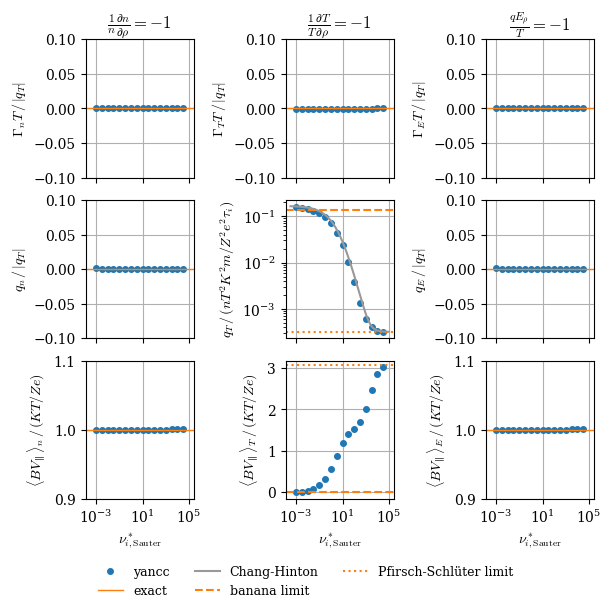

In [12]:
d = as_arrays(data["nu_scan"])
order = np.argsort(d["nu"])
d = {k: v[order] for k, v in d.items()}
nu, eps = d["nu"], float(d["eps"][0])
f_t = trapped_fraction(eps)
B2 = fsa(lambda B, t: B**2, eps)
Bm2 = fsa(lambda B, t: B**-2, eps)

# banana and Pfirsch-Schluter limits
Cq_ban = 0.92 * f_t / B2
Cq_ps = 25 / (4 * KAPPA_PAR) * (Bm2 - 1 / B2)
V_ban = 1 - 1.17 * (1 - f_t)
V_ps = 1 + 1.8 + 0.27 * hazeltine_b(eps)
nu_c = np.geomspace(nu.min() / 3, nu.max() * 3, 300)
Cq_ch = chang_hinton(nu_c * d["mu_star"][0] / nu[0], eps, B2, Bm2)
gs = np.abs(d["q_T"]) / T_J

fig, ax = plt.subplots(3, 3, figsize=(6, 6), sharex=True, constrained_layout=True)
cols = {
    "T": "$\\frac{1}{T}\\frac{\\partial T}{\\partial \\rho}=-1$ ",
    "n": "$\\frac{1}{n}\\frac{\\partial n}{\\partial \\rho}=-1$",
    "E": "$\\frac{q E_\\rho}{T} = -1$",
}


def zero_lim(ys):
    return max(0.1, 1.3 * max(np.nanmax(np.abs(y)) for y in ys))


zlim = zero_lim(
    [d["q_n"] / np.abs(d["q_T"]), d["q_E"] / np.abs(d["q_T"])]
    + [d[f"g_{s}"] / gs for s in "TnE"]
)
vlim = zero_lim([d[f"V_{s}"] / d["V_dia"] - 1 for s in "nE"])


def plot_yancc(a, y, s):
    """Plot yancc against nu*, marking solves that did not converge."""
    ok = converged(d, s)
    a.plot(nu, y, color="C0", marker="o", ls="", label="yancc")
    if (~ok).any():
        a.plot(
            nu[~ok], y[~ok], ls="", marker="o", mfc="w", mec="C0", label="not converged"
        )


for j, s in enumerate("nTE"):
    ax[0, j].set_title(cols[s])
    plot_yancc(ax[0, j], d[f"g_{s}"] / gs, s)
    plot_yancc(ax[2, j], d[f"V_{s}"] / d["V_dia"], s)
    if s == "T":
        plot_yancc(ax[1, j], d["q_T"] / d["qscale"], "T")
        ax[1, j].semilogy(nu_c, Cq_ch, color="0.6", label="Chang-Hinton")
        ax[1, j].axhline(Cq_ban, color="tab:orange", ls="--", label="banana limit")
        ax[1, j].axhline(
            Cq_ps, color="tab:orange", ls=":", label="Pfirsch-Schlüter limit"
        )
        ax[1, j].set_ylabel(r"$q_T \,/\, (n T^2 K^2 m / Z^2 e^2 \tau_i)$")
        ax[2, j].axhline(V_ban, color="tab:orange", ls="--")
        ax[2, j].axhline(V_ps, color="tab:orange", ls=":")
    else:
        plot_yancc(ax[1, j], d[f"q_{s}"] / np.abs(d["q_T"]), s)
        ax[1, j].axhline(0.0, color="tab:orange", lw=1, label="exact")
        ax[1, j].set_ylabel(rf"$q_{s} \,/\, |q_T|$")
        ax[1, j].set_ylim(-zlim, zlim)
        ax[2, j].axhline(1.0, color="tab:orange", lw=1)
        ax[2, j].set_ylim(1 - vlim, 1 + vlim)
    ax[0, j].axhline(0.0, color="tab:orange", lw=1)
    ax[0, j].set_ylabel(rf"$\Gamma_{s} T \,/\, |q_T|$")
    ax[0, j].set_ylim(-zlim, zlim)
    ax[2, j].set_ylabel(rf"$\langle B V_\parallel \rangle_{s} \,/\, (K T / Z e)$")
    ax[2, j].set_xlabel(r"$\nu^*_{i, \mathrm{Sauter}}$")
for a in ax.flat:
    a.set_xscale("log")
    a.grid(True)
    a.set_xticks([1e-3, 1e1, 1e5])
handles, labels = ax[1, 2].get_legend_handles_labels()
h1, l1 = ax[1, 1].get_legend_handles_labels()
by_label = dict(zip(labels + l1, handles + h1))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="outside lower center",
    ncol=3,
    fontsize=9,
    frameon=False,
)

In [13]:
fig.savefig("benchmark_circular_tokamak_nustar.pdf")
fig.savefig("benchmark_circular_tokamak_nustar.png")

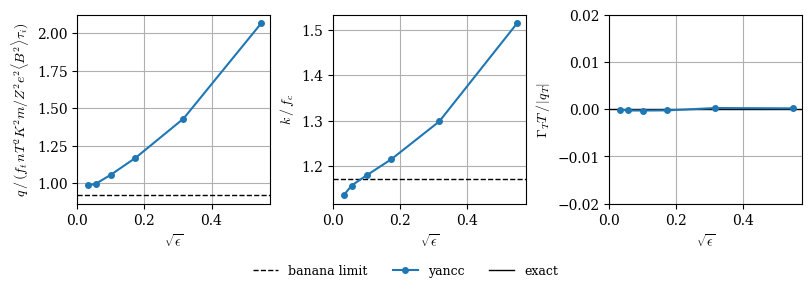

In [12]:
e_ = as_arrays(data["eps_scan"])
order = np.argsort(e_["eps"])
e_ = {k: v[order] for k, v in e_.items()}
f_t_e = np.array([trapped_fraction(x) for x in e_["eps"]])
B2_e = np.array([fsa(lambda B, t: B**2, x) for x in e_["eps"]])
s_eps = np.sqrt(e_["eps"])

# coefficients in the normalization of (11.29) and (11.31), each tending to its
# limit as eps -> 0
C_q = e_["q_T"] / (f_t_e * e_["qscale"] / B2_e)
C_k = (e_["V_n"] - e_["V_T"]) / e_["V_n"] / (1 - f_t_e)
G_T = e_["g_T"] * T_J / np.abs(e_["q_T"])

fig2, ax2 = plt.subplots(1, 3, figsize=(8, 2.8), constrained_layout=True)
for a, y, lim, lab in [
    (
        ax2[0],
        C_q,
        0.92,
        r"$q \,/\, (f_t\, n T^2 K^2 m / Z^2 e^2 \langle B^2\rangle \tau_i)$",
    ),
    (ax2[1], C_k, 1.17, r"$k \,/\, f_c$"),
    (ax2[2], G_T, 0.0, r"$\Gamma_T T \,/\, |q_T|$"),
]:
    a.axhline(
        lim,
        color="tab:orange",
        ls="--" if lim else "-",
        lw=1,
        label="banana limit" if lim else "exact",
    )
    a.plot(s_eps, y, color="C0", marker="o", label="yancc")
    a.set_xlim(0, None)
    a.set_xlabel(r"$\sqrt{\epsilon}$")
    a.set_ylabel(lab)
    a.grid(True)
glim = max(0.02, 1.3 * np.nanmax(np.abs(G_T)))
ax2[2].set_ylim(-glim, glim)
handles = (
    ax2[0].get_legend_handles_labels()[0] + ax2[2].get_legend_handles_labels()[0][:1]
)
fig2.legend(
    handles,
    [h.get_label() for h in handles],
    loc="outside lower center",
    ncol=3,
    fontsize=9,
    frameon=False,
)

In [13]:
fig2.savefig("benchmark_circular_tokamak_eps.pdf")
fig2.savefig("benchmark_circular_tokamak_eps.png")